In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler, LabelEncoder, PolynomialFeatures
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.feature_selection import SelectKBest, f_regression, RFE
from sklearn.ensemble import RandomForestRegressor
from imblearn.over_sampling import SMOTE
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

# Load the dataset
df = pd.read_csv('data/CarPrice_Assignment.csv')

print("Dataset Shape:", df.shape)
print("\nFirst few rows:")
df.head()

Dataset Shape: (205, 26)

First few rows:


,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [12]:
# Basic data exploration
print("Dataset Info:")
print(df.info())
print("\nMissing Values:")
print(df.isnull().sum())
print("\nDescriptive Statistics:")
df.describe()

Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


**Handling Missing Data**

In [3]:
# Check for missing values
print("Missing values before imputation:")
missing_values = df.isnull().sum()
print(missing_values[missing_values > 0])

# Since there are no missing values in this dataset, let's demonstrate imputation techniques
# by artificially creating some missing values for demonstration

# Create a copy and introduce missing values for demonstration
df_demo = df.copy()

# Introduce 5% missing values in numeric columns
np.random.seed(42)
numeric_cols = df_demo.select_dtypes(include=[np.number]).columns
for col in numeric_cols[:5]:  # First 5 numeric columns
    mask = np.random.random(len(df_demo)) < 0.05
    df_demo.loc[mask, col] = np.nan

print("\nMissing values after introducing artificial missing values:")
print(df_demo.isnull().sum()[df_demo.isnull().sum() > 0])

# Imputation techniques
print("\n--- Imputation Techniques ---")

# 1. Mean Imputation for numeric columns
df_mean = df_demo.copy()
numeric_imputer = SimpleImputer(strategy='mean')
df_mean[numeric_cols] = numeric_imputer.fit_transform(df_mean[numeric_cols])

# 2. Median Imputation
df_median = df_demo.copy()
numeric_imputer_median = SimpleImputer(strategy='median')
df_median[numeric_cols] = numeric_imputer_median.fit_transform(df_median[numeric_cols])

# 3. KNN Imputation
df_knn = df_demo.copy()
knn_imputer = KNNImputer(n_neighbors=5)
df_knn[numeric_cols] = knn_imputer.fit_transform(df_knn[numeric_cols])

# 4. Mode Imputation for categorical columns
categorical_cols = df_demo.select_dtypes(include=['object']).columns
categorical_imputer = SimpleImputer(strategy='most_frequent')
df_mean[categorical_cols] = categorical_imputer.fit_transform(df_mean[categorical_cols])

print("Missing values after imputation (mean strategy):", df_mean.isnull().sum().sum())

Missing values before imputation:
Series([], dtype: int64)

Missing values after introducing artificial missing values:
car_ID       11
symboling    16
wheelbase    10
carlength     4
carwidth     15
dtype: int64

--- Imputation Techniques ---
Missing values after imputation (mean strategy): 0


**Outlier Detection and Handling**


--- Outlier Detection and Handling ---


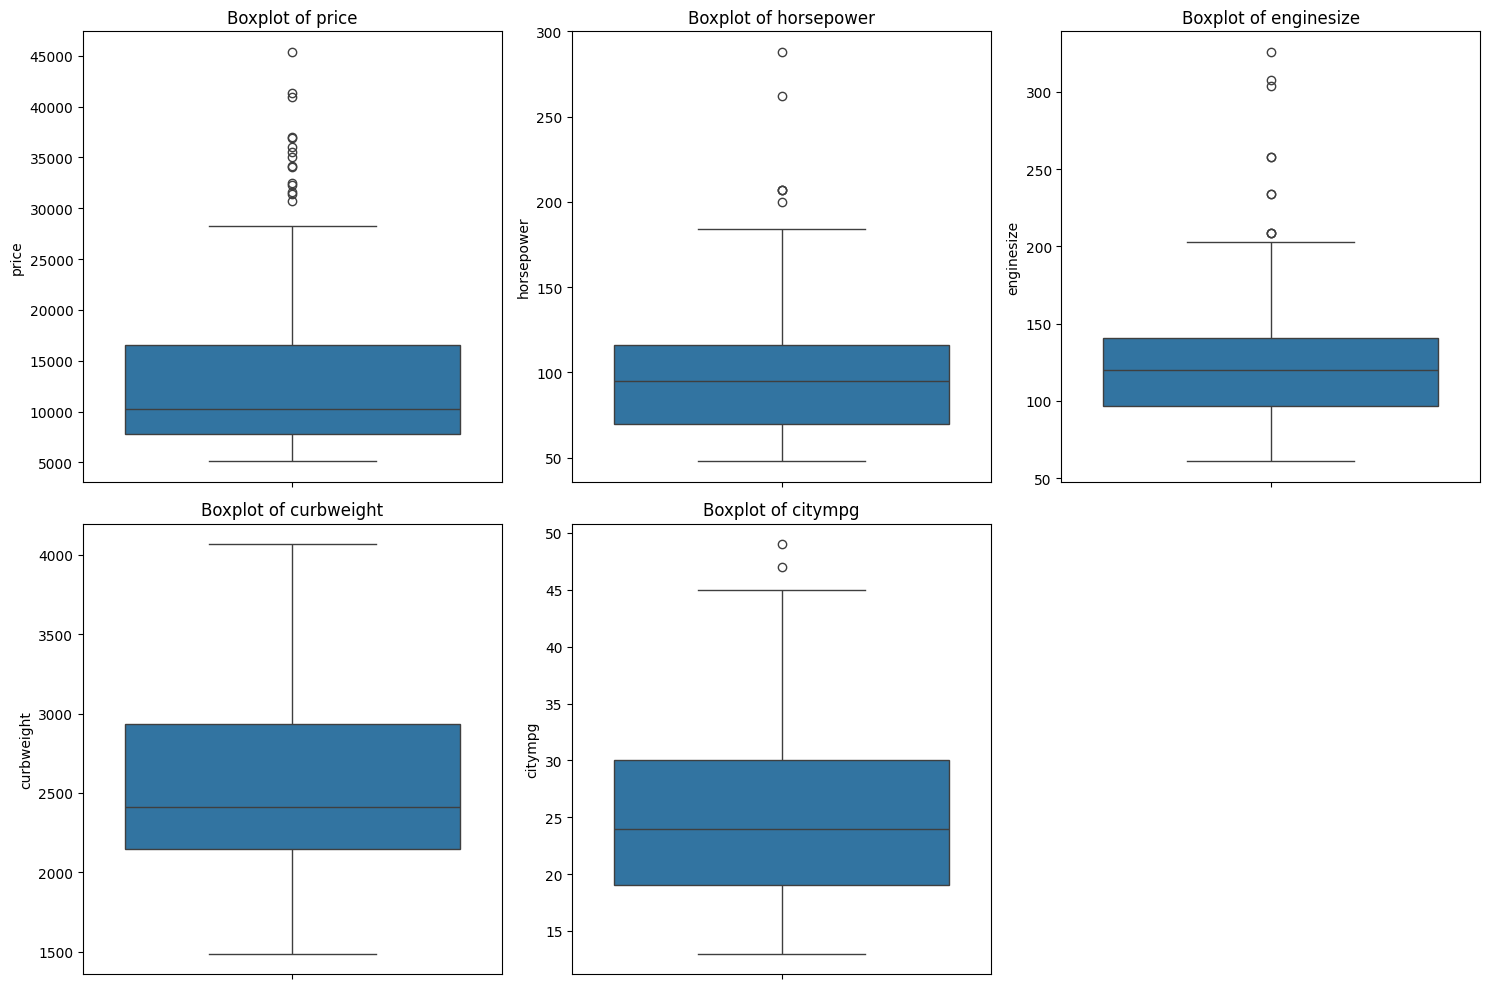


Outlier detection using Z-score (threshold = 3):
Number of outliers detected: 24
Number of outliers detected using IQR: 18
Outliers handled using capping method


In [4]:
print("\n--- Outlier Detection and Handling ---")

# Use the original dataset without artificial missing values for outlier detection
df_clean = df.copy()

# Identify numeric columns for outlier detection
numeric_cols_outlier = ['price', 'horsepower', 'enginesize', 'curbweight', 'citympg']

# Visualize outliers
plt.figure(figsize=(15, 10))
for i, col in enumerate(numeric_cols_outlier, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(y=df_clean[col])
    plt.title(f'Boxplot of {col}')
plt.tight_layout()
plt.show()

# Outlier detection using Z-score
print("\nOutlier detection using Z-score (threshold = 3):")
z_scores = np.abs(stats.zscore(df_clean[numeric_cols]))
outliers = (z_scores > 3).any(axis=1)
print(f"Number of outliers detected: {outliers.sum()}")

# Outlier detection using IQR
def detect_outliers_iqr(df, columns):
    outlier_mask = pd.Series([False] * len(df))
    for col in columns:
        Q1 = df[col].quantile(0.25)
        Q3 = df[col].quantile(0.75)
        IQR = Q3 - Q1
        lower_bound = Q1 - 1.5 * IQR
        upper_bound = Q3 + 1.5 * IQR
        col_outliers = (df[col] < lower_bound) | (df[col] > upper_bound)
        outlier_mask = outlier_mask | col_outliers
    return outlier_mask

iqr_outliers = detect_outliers_iqr(df_clean, numeric_cols_outlier)
print(f"Number of outliers detected using IQR: {iqr_outliers.sum()}")

# Outlier handling - Capping (Winsorizing)
df_no_outliers = df_clean.copy()
for col in numeric_cols_outlier:
    Q1 = df_no_outliers[col].quantile(0.25)
    Q3 = df_no_outliers[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    
    # Cap the outliers
    df_no_outliers[col] = np.where(df_no_outliers[col] < lower_bound, lower_bound, df_no_outliers[col])
    df_no_outliers[col] = np.where(df_no_outliers[col] > upper_bound, upper_bound, df_no_outliers[col])

print("Outliers handled using capping method")

**Encoding Categorical Data**

In [5]:
print("\n--- Encoding Categorical Data ---")

# Extract car company from CarName
df_clean['carCompany'] = df_clean['CarName'].apply(lambda x: x.split()[0])

# Identify categorical columns
categorical_columns = ['fueltype', 'aspiration', 'doornumber', 'carbody', 
                      'drivewheel', 'enginelocation', 'enginetype', 
                      'cylindernumber', 'fuelsystem', 'carCompany']

print("Original categorical columns:")
for col in categorical_columns:
    print(f"{col}: {df_clean[col].nunique()} unique values")

# Label Encoding for ordinal categories
df_encoded = df_clean.copy()
label_encoders = {}

for col in ['doornumber', 'cylindernumber']:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df_encoded[col])
    label_encoders[col] = le
    print(f"Label encoded {col}: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# One-Hot Encoding for nominal categories
nominal_columns = [col for col in categorical_columns if col not in ['doornumber', 'cylindernumber']]
df_encoded = pd.get_dummies(df_encoded, columns=nominal_columns, prefix=nominal_columns)

print(f"\nShape after encoding: {df_encoded.shape}")
print(f"Number of features after encoding: {len(df_encoded.columns)}")


--- Encoding Categorical Data ---
Original categorical columns:
fueltype: 2 unique values
aspiration: 2 unique values
doornumber: 2 unique values
carbody: 5 unique values
drivewheel: 3 unique values
enginelocation: 2 unique values
enginetype: 7 unique values
cylindernumber: 7 unique values
fuelsystem: 8 unique values
carCompany: 28 unique values
Label encoded doornumber: {'four': 0, 'two': 1}
Label encoded cylindernumber: {'eight': 0, 'five': 1, 'four': 2, 'six': 3, 'three': 4, 'twelve': 5, 'two': 6}

Shape after encoding: (205, 76)
Number of features after encoding: 76


**Data Scaling & Normalization**


--- Data Scaling & Normalization ---
Features to scale: ['symboling', 'doornumber', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 'cylindernumber', 'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 'highwaympg']
Scaling completed:
Standardized data - Mean ~ 0, Std ~ 1
Min-Max scaled data - Range [0, 1]


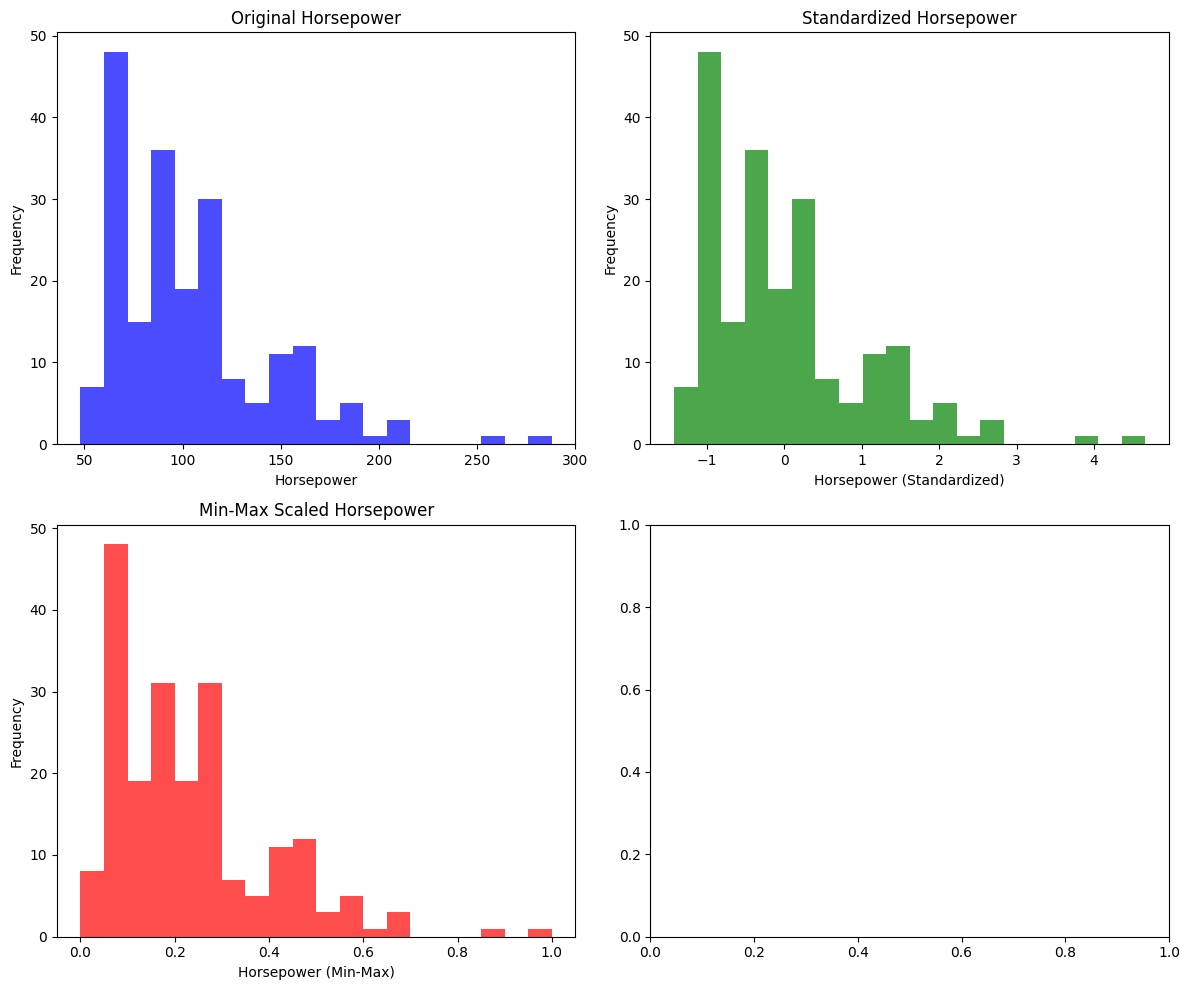

In [6]:
print("\n--- Data Scaling & Normalization ---")

# Separate features and target
X = df_encoded.drop(['car_ID', 'CarName', 'price'], axis=1)
y = df_encoded['price']

# Identify numeric columns for scaling
numeric_cols_scale = X.select_dtypes(include=[np.number]).columns

print(f"Features to scale: {list(numeric_cols_scale)}")

# Standardization (Z-score Normalization)
scaler_standard = StandardScaler()
X_standardized = X.copy()
X_standardized[numeric_cols_scale] = scaler_standard.fit_transform(X_standardized[numeric_cols_scale])

# Min-Max Scaling
scaler_minmax = MinMaxScaler()
X_minmax = X.copy()
X_minmax[numeric_cols_scale] = scaler_minmax.fit_transform(X_minmax[numeric_cols_scale])

print("Scaling completed:")
print("Standardized data - Mean ~ 0, Std ~ 1")
print("Min-Max scaled data - Range [0, 1]")

# Compare distributions
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Original data
axes[0, 0].hist(X['horsepower'], bins=20, alpha=0.7, color='blue')
axes[0, 0].set_title('Original Horsepower')
axes[0, 0].set_xlabel('Horsepower')
axes[0, 0].set_ylabel('Frequency')

# Standardized data
axes[0, 1].hist(X_standardized['horsepower'], bins=20, alpha=0.7, color='green')
axes[0, 1].set_title('Standardized Horsepower')
axes[0, 1].set_xlabel('Horsepower (Standardized)')
axes[0, 1].set_ylabel('Frequency')

# Min-Max scaled data
axes[1, 0].hist(X_minmax['horsepower'], bins=20, alpha=0.7, color='red')
axes[1, 0].set_title('Min-Max Scaled Horsepower')
axes[1, 0].set_xlabel('Horsepower (Min-Max)')
axes[1, 0].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

**Feature Selection & Feature Engineering**

In [7]:
print("\n--- Feature Selection & Feature Engineering ---")

# Use standardized data for feature selection
X_scaled = X_standardized.copy()

# Feature Engineering
X_engineered = X_scaled.copy()

# Create new features
X_engineered['power_to_weight'] = X_engineered['horsepower'] / (X_engineered['curbweight'] + 1)
X_engineered['size_ratio'] = X_engineered['carlength'] * X_engineered['carwidth'] * X_engineered['carheight']
X_engineered['mpg_combined'] = (X_engineered['citympg'] + X_engineered['highwaympg']) / 2
X_engineered['engine_efficiency'] = X_engineered['horsepower'] / (X_engineered['enginesize'] + 1)

print("New engineered features created:")
print("- power_to_weight: Horsepower per unit weight")
print("- size_ratio: Product of length, width, and height")
print("- mpg_combined: Average of city and highway MPG")
print("- engine_efficiency: Horsepower per engine size")

# Feature Selection
print("\n--- Feature Selection ---")

# 1. Correlation Analysis
correlation_matrix = pd.concat([X_engineered, y], axis=1).corr()
price_correlation = correlation_matrix['price'].sort_values(ascending=False)

print("Top 10 features correlated with price:")
print(price_correlation.head(10))

# 2. SelectKBest
selector_kbest = SelectKBest(score_func=f_regression, k=15)
X_kbest = selector_kbest.fit_transform(X_engineered, y)
selected_features_kbest = X_engineered.columns[selector_kbest.get_support()]

print(f"\nTop 15 features selected by SelectKBest:")
print(list(selected_features_kbest))

# 3. Recursive Feature Elimination (RFE)
model_rfe = LinearRegression()
rfe = RFE(estimator=model_rfe, n_features_to_select=15)
X_rfe = rfe.fit_transform(X_engineered, y)
selected_features_rfe = X_engineered.columns[rfe.get_support()]

print(f"\nTop 15 features selected by RFE:")
print(list(selected_features_rfe))

# 4. Feature Importance using Random Forest
rf = RandomForestRegressor(n_estimators=100, random_state=42)
rf.fit(X_engineered, y)
feature_importance = pd.DataFrame({
    'feature': X_engineered.columns,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

print(f"\nTop 15 features by Random Forest importance:")
print(feature_importance.head(15))

# Select final features based on consensus
final_features = list(set(selected_features_kbest) & set(selected_features_rfe) | 
                    set(feature_importance.head(15)['feature']))
X_final = X_engineered[final_features]

print(f"\nFinal selected features ({len(final_features)}):")
print(final_features)


--- Feature Selection & Feature Engineering ---
New engineered features created:
- power_to_weight: Horsepower per unit weight
- size_ratio: Product of length, width, and height
- mpg_combined: Average of city and highway MPG
- engine_efficiency: Horsepower per engine size

--- Feature Selection ---
Top 10 features correlated with price:
price              1.000000
enginesize         0.874145
curbweight         0.835305
horsepower         0.808139
carwidth           0.759325
carlength          0.682920
drivewheel_rwd     0.638957
wheelbase          0.577816
boreratio          0.553173
fuelsystem_mpfi    0.517075
Name: price, dtype: float64

Top 15 features selected by SelectKBest:
['wheelbase', 'carlength', 'carwidth', 'curbweight', 'enginesize', 'boreratio', 'horsepower', 'citympg', 'highwaympg', 'drivewheel_fwd', 'drivewheel_rwd', 'fuelsystem_2bbl', 'fuelsystem_mpfi', 'carCompany_buick', 'mpg_combined']

Top 15 features selected by RFE:
['carwidth', 'enginesize', 'carbody_convertibl

**Handling Imbalanced Data**


--- Handling Imbalanced Data ---


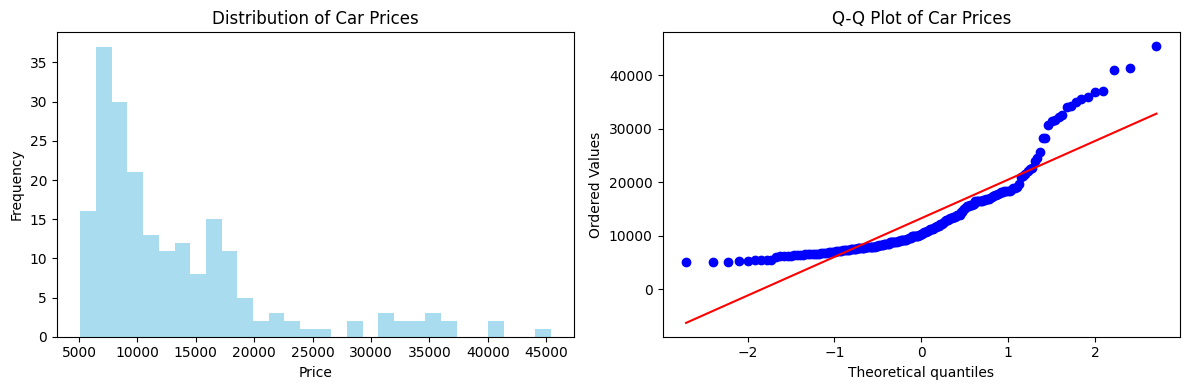

Skewness of price distribution: 1.778
Applied log transformation to target variable

Class distribution (0: Affordable, 1: Expensive):
price
0    103
1    102
Name: count, dtype: int64

After SMOTE:
Original shape: (205, 16)
After SMOTE shape: (206, 16)
Class distribution after SMOTE:
price
1    103
0    103
Name: count, dtype: int64


In [8]:
print("\n--- Handling Imbalanced Data ---")

# For regression, we typically don't use SMOTE directly on continuous target
# Instead, we can analyze the target distribution and consider transformations

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.hist(y, bins=30, alpha=0.7, color='skyblue')
plt.title('Distribution of Car Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')

plt.subplot(1, 2, 2)
stats.probplot(y, dist="norm", plot=plt)
plt.title('Q-Q Plot of Car Prices')

plt.tight_layout()
plt.show()

# Check if we need to handle skewness
skewness = y.skew()
print(f"Skewness of price distribution: {skewness:.3f}")

if abs(skewness) > 1:
    # Apply log transformation for highly skewed data
    y_transformed = np.log1p(y)
    print("Applied log transformation to target variable")
else:
    y_transformed = y.copy()
    print("No transformation needed for target variable")

# For demonstration, let's create a classification problem to show SMOTE
# Convert to classification: Expensive vs Affordable
price_threshold = y.median()
y_class = (y > price_threshold).astype(int)

print(f"\nClass distribution (0: Affordable, 1: Expensive):")
print(y_class.value_counts())

# Apply SMOTE for the classification problem
smote = SMOTE(random_state=42)
X_smote, y_smote = smote.fit_resample(X_final, y_class)

print(f"\nAfter SMOTE:")
print(f"Original shape: {X_final.shape}")
print(f"After SMOTE shape: {X_smote.shape}")
print("Class distribution after SMOTE:")
print(pd.Series(y_smote).value_counts())

**Regression Models and Evaluation**

In [9]:
print("\n--- Regression Models and Evaluation ---")

# Prepare data for regression (using original continuous target)
X_train, X_test, y_train, y_test = train_test_split(
    X_final, y, test_size=0.2, random_state=42
)

# Also create a version with transformed target for comparison
X_train_trans, X_test_trans, y_train_trans, y_test_trans = train_test_split(
    X_final, y_transformed, test_size=0.2, random_state=42
)

# Dictionary to store results
results = {}

def evaluate_model(model, X_train, X_test, y_train, y_test, model_name, results_dict):
    """Helper function to evaluate regression models"""
    # Train the model
    model.fit(X_train, y_train)
    
    # Make predictions
    y_pred = model.predict(X_test)
    
    # Calculate metrics
    r2 = r2_score(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mse)
    
    # Store results
    results_dict[model_name] = {
        'r2_score': r2,
        'mse': mse,
        'mae': mae,
        'rmse': rmse,
        'model': model
    }
    
    print(f"\n{model_name} Results:")
    print(f"R² Score: {r2:.4f}")
    print(f"MSE: {mse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"RMSE: {rmse:.2f}")
    
    return y_pred

# 7. Simple Linear Regression (using most correlated feature)
most_correlated_feature = price_correlation.index[1]  # Skip 'price' itself
print(f"\nSimple Linear Regression using: {most_correlated_feature}")

X_simple_train = X_train[[most_correlated_feature]]
X_simple_test = X_test[[most_correlated_feature]]

simple_lr = LinearRegression()
y_pred_simple = evaluate_model(simple_lr, X_simple_train, X_simple_test, 
                             y_train, y_test, "Simple Linear Regression", results)

# 8. Multiple Linear Regression
multiple_lr = LinearRegression()
y_pred_multiple = evaluate_model(multiple_lr, X_train, X_test, 
                               y_train, y_test, "Multiple Linear Regression", results)

# 9. Polynomial Regression
print("\n--- Polynomial Regression ---")
degrees = [2, 3]
for degree in degrees:
    poly = PolynomialFeatures(degree=degree, include_bias=False)
    X_poly_train = poly.fit_transform(X_train)
    X_poly_test = poly.transform(X_test)
    
    poly_lr = LinearRegression()
    y_pred_poly = evaluate_model(poly_lr, X_poly_train, X_poly_test, 
                               y_train, y_test, f"Polynomial Regression (deg {degree})", results)

# 10. Regularization Models
print("\n--- Regularization Models ---")

# Ridge Regression
ridge = Ridge(alpha=1.0)
y_pred_ridge = evaluate_model(ridge, X_train, X_test, 
                            y_train, y_test, "Ridge Regression", results)

# Lasso Regression
lasso = Lasso(alpha=0.1)
y_pred_lasso = evaluate_model(lasso, X_train, X_test, 
                            y_train, y_test, "Lasso Regression", results)

# Compare all models
print("\n" + "="*50)
print("MODEL COMPARISON SUMMARY")
print("="*50)

comparison_df = pd.DataFrame({
    'Model': list(results.keys()),
    'R² Score': [results[model]['r2_score'] for model in results],
    'MSE': [results[model]['mse'] for model in results],
    'MAE': [results[model]['mae'] for model in results],
    'RMSE': [results[model]['rmse'] for model in results]
}).sort_values('R² Score', ascending=False)

print(comparison_df.round(4))


--- Regression Models and Evaluation ---

Simple Linear Regression using: enginesize

Simple Linear Regression Results:
R² Score: 0.8041
MSE: 15465458.97
MAE: 2748.69
RMSE: 3932.61

Multiple Linear Regression Results:
R² Score: 0.8567
MSE: 11310643.74
MAE: 2501.52
RMSE: 3363.13

--- Polynomial Regression ---

Polynomial Regression (deg 2) Results:
R² Score: -322.0081
MSE: 25499555882.18
MAE: 38843.13
RMSE: 159685.80

Polynomial Regression (deg 3) Results:
R² Score: -311294750249.1794
MSE: 24574859263477985280.00
MAE: 775417228.99
RMSE: 4957303628.33

--- Regularization Models ---

Ridge Regression Results:
R² Score: 0.8693
MSE: 10318934.13
MAE: 2319.86
RMSE: 3212.31

Lasso Regression Results:
R² Score: 0.8568
MSE: 11301708.18
MAE: 2499.98
RMSE: 3361.80

MODEL COMPARISON SUMMARY
                           Model      R² Score           MSE           MAE  \
4               Ridge Regression  8.693000e-01  1.031893e+07  2.319855e+03   
5               Lasso Regression  8.568000e-01  1.1301

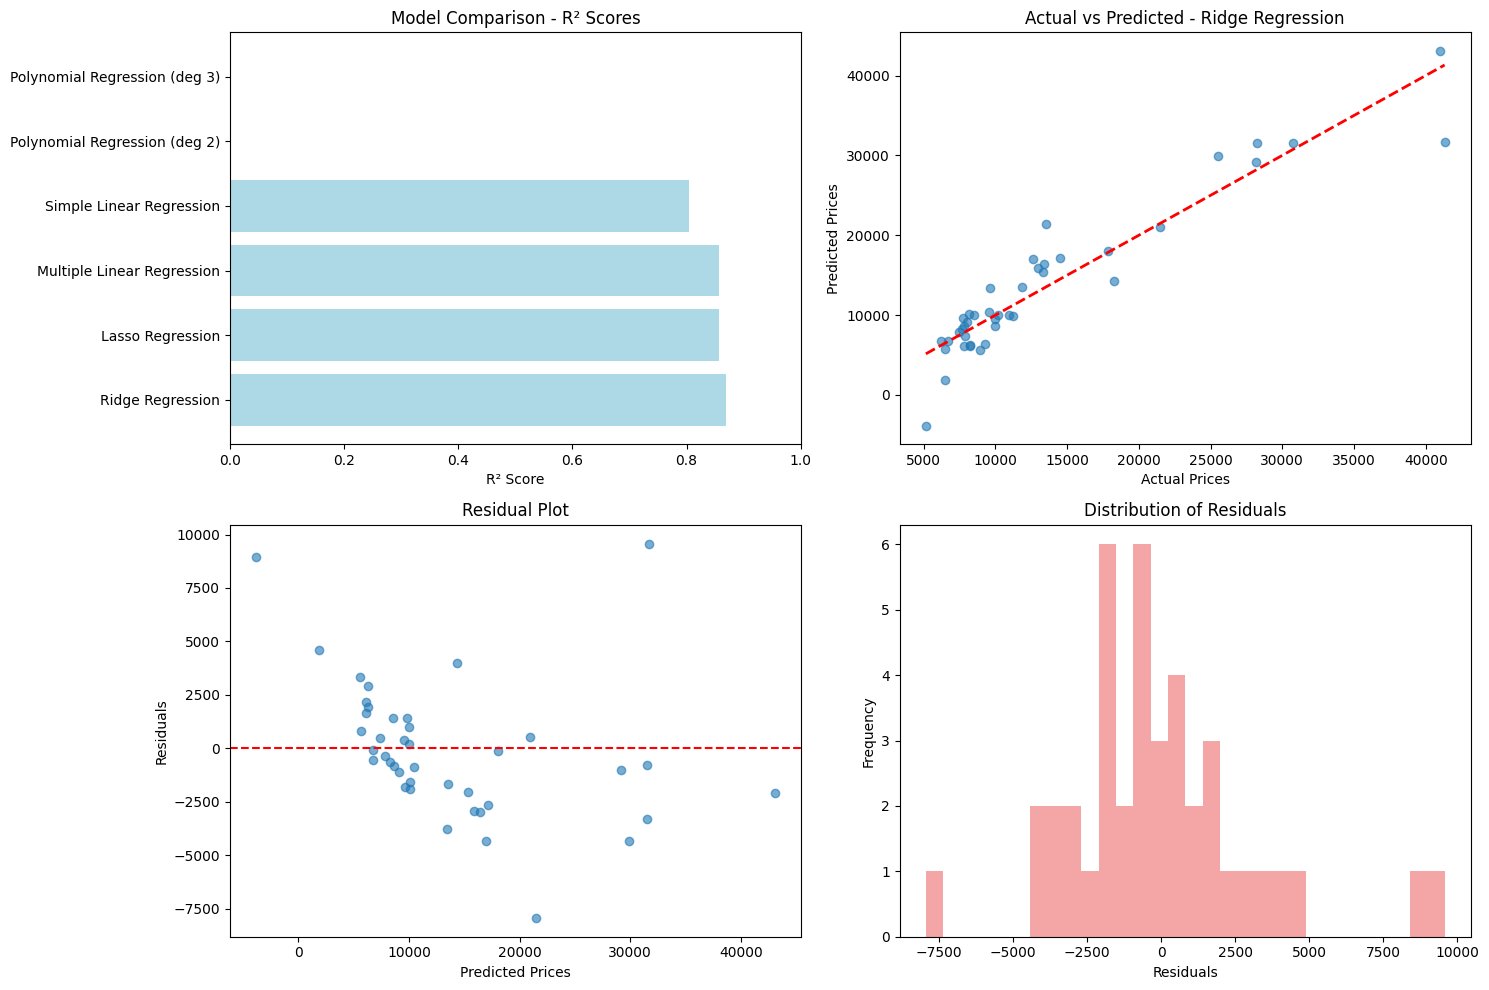


--- Feature Importance from Lasso Regression ---
Top 10 most important features (Lasso):
             feature  coefficient
15  carCompany_buick  8540.091191
6     carCompany_bmw  6803.904000
13      mpg_combined -5176.219796
9         highwaympg  3974.452549
4         enginesize  3105.944649
7         horsepower  2005.124910
10  compressionratio  1364.009107
12        curbweight  1015.987654
11           peakrpm  1003.488597
8           carwidth   894.632618

ANALYSIS COMPLETE
Best Model: Ridge Regression
Best R² Score: 0.8693
Best RMSE: 3212.31


In [10]:
# Visualization of model performance
plt.figure(figsize=(15, 10))

# 1. Model Comparison
plt.subplot(2, 2, 1)
models = comparison_df['Model']
r2_scores = comparison_df['R² Score']
plt.barh(models, r2_scores, color='lightblue')
plt.xlabel('R² Score')
plt.title('Model Comparison - R² Scores')
plt.xlim(0, 1)

# 2. Actual vs Predicted for best model
best_model_name = comparison_df.iloc[0]['Model']
best_model = results[best_model_name]['model']
y_pred_best = best_model.predict(X_test)

plt.subplot(2, 2, 2)
plt.scatter(y_test, y_pred_best, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel('Actual Prices')
plt.ylabel('Predicted Prices')
plt.title(f'Actual vs Predicted - {best_model_name}')

# 3. Residuals plot
plt.subplot(2, 2, 3)
residuals = y_test - y_pred_best
plt.scatter(y_pred_best, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted Prices')
plt.ylabel('Residuals')
plt.title('Residual Plot')

# 4. Error distribution
plt.subplot(2, 2, 4)
plt.hist(residuals, bins=30, alpha=0.7, color='lightcoral')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Distribution of Residuals')

plt.tight_layout()
plt.show()

# Feature importance from Lasso
print("\n--- Feature Importance from Lasso Regression ---")
lasso_coef = pd.DataFrame({
    'feature': X_final.columns,
    'coefficient': lasso.coef_
}).sort_values('coefficient', key=abs, ascending=False)

print("Top 10 most important features (Lasso):")
print(lasso_coef.head(10))

print("\n" + "="*60)
print("ANALYSIS COMPLETE")
print("="*60)
print(f"Best Model: {best_model_name}")
print(f"Best R² Score: {comparison_df.iloc[0]['R² Score']:.4f}")
print(f"Best RMSE: {comparison_df.iloc[0]['RMSE']:.2f}")